In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad

drogas = pd.read_parquet('/mnt/lustre/scratch/nlsas/home/ulc/co/mao/drug_metadata.parquet')
l_cel =pd.read_parquet('/home/ulc/co/mao/0.parquet')
adata = ad.read('/mnt/lustre/scratch/nlsas/home/ulc/co/mao/modelo_prueba_final_fast_convergence/adata/mofa_adata_30f.h5ad')
import re

l_cel['cell_name'] = (l_cel['cell_name']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.upper()
    .str.replace('/', '_')
)


/mnt/netapp2/Store_uni/home/ulc/co/mao/SOFTWARE/miniconda3/envs/sc_2/lib/python3.11/site-packages/anndata/__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [12]:
moa = drogas[['drug','moa-fine']]
moa =moa.groupby('moa-fine').size().sort_values(ascending=True)

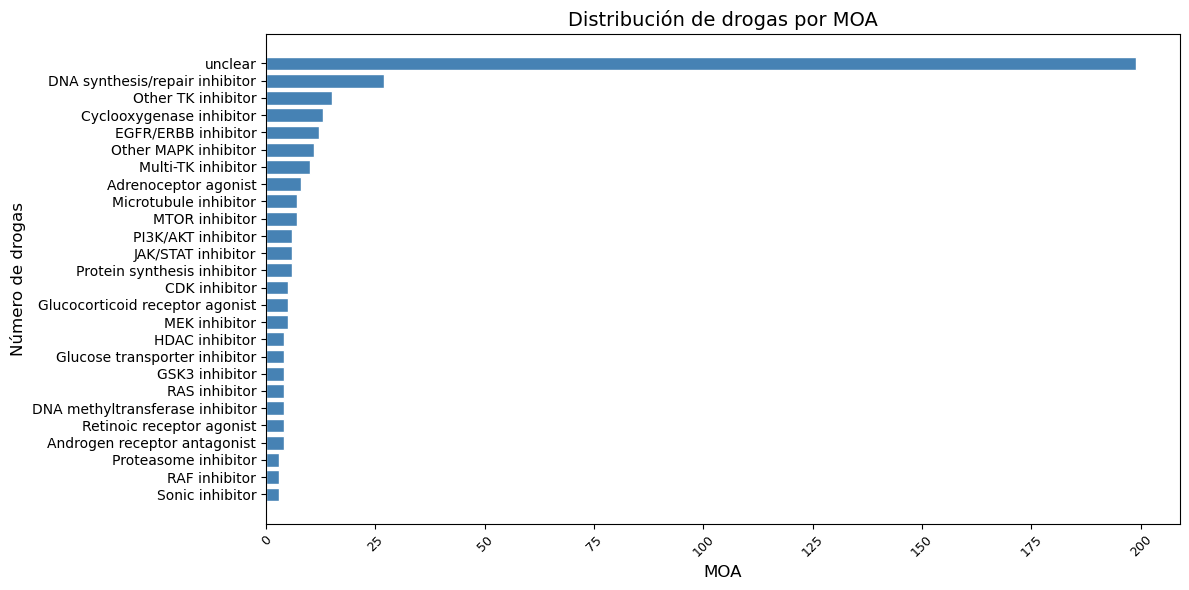

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(moa.index, moa.values, color='steelblue', edgecolor='white')

ax.set_xlabel('MOA', fontsize=12)
ax.set_ylabel('Número de drogas', fontsize=12)
ax.set_title('Distribución de drogas por MOA', fontsize=14)
ax.tick_params(axis='x', labelsize=9, rotation=45)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig('barchart_moa.png', dpi=300, bbox_inches='tight')
plt.show()

In [62]:
l_cel = l_cel[['cell_name','Organ']]
 
linea_cel= adata.uns['mofa_views']
lcel = pd.DataFrame(data = linea_cel, columns=['cell_name'])

In [63]:
tabla = pd.merge(lcel, l_cel, on='cell_name', how='inner')
tabla['cell_name'].nunique()

47

In [ ]:
tabla = pd.merge(lcel,l_cel, on='cell_name', how='inner').drop_duplicates()
tabla = tabla.groupby('Organ').size()

tabla.index
tabla.value

Index(['Bladder/Urinary Tract', 'Bowel', 'Breast', 'CNS/Brain', 'Cervix',
       'Esophagus/Stomach', 'Kidney', 'Liver', 'Lung', 'Pancreas',
       'Peripheral Nervous System', 'Skin', 'Uterus'],
      dtype='object', name='Organ')

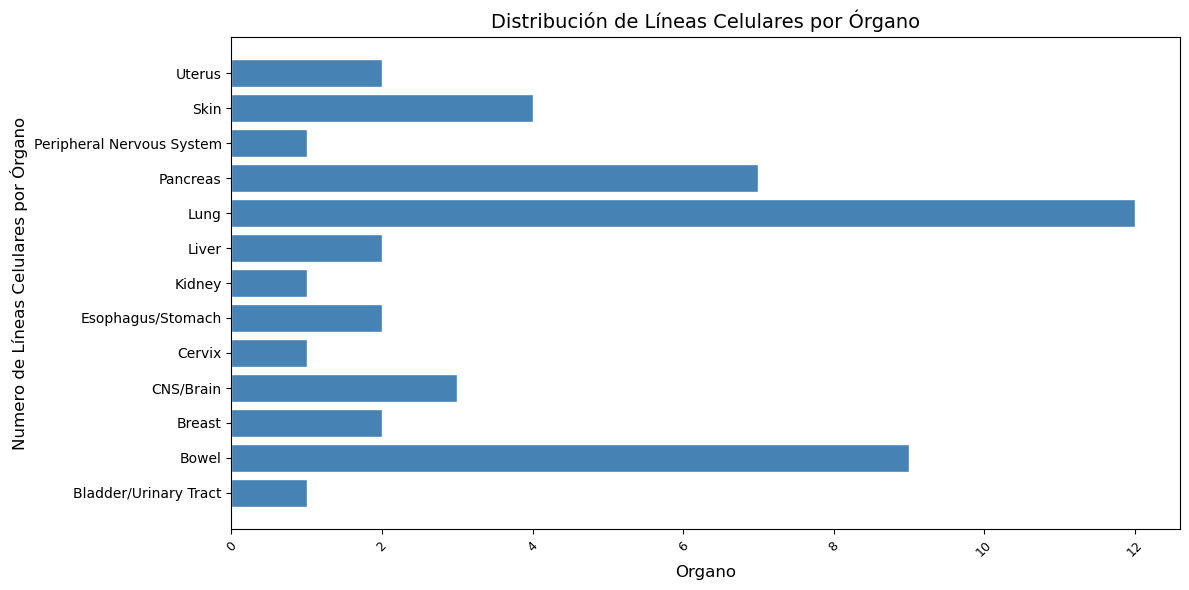

In [69]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(tabla.index, tabla.values, color='steelblue', edgecolor='white')

ax.set_xlabel('Organo', fontsize=12)
ax.set_ylabel('Numero de Líneas Celulares por Órgano', fontsize=12)
ax.set_title('Distribución de Líneas Celulares por Órgano', fontsize=14)
ax.tick_params(axis='x', labelsize=9, rotation=45)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig('barchart_organo.png', dpi=300, bbox_inches='tight')
plt.show()